## Gaming Habits and Academic Performance Analysis
**Python Section B Group 4**\
**Dataset:** Gaming vs Academic Performance  \
**Source:** Kaggle – https://www.kaggle.com/datasets/aiexplorer77/gaming-vs-academic-performance

## Analytical Questions

### Predictive Risk & Correlation Hierarchy:
How do different lifestyle factors compare in their influence on academic success? Specifically, does the "Academic Risk Score" provide a better prediction of grades than individual factors like study hours, sleep hours, or gaming hours alone?  


### The Stress-Performance Trade-off:
Does increased gaming serve as an effective stress-relief mechanism at the cost of academic grades, or does it contribute to a cycle of low performance and high stress?  

### Cognitive Skills vs. Academic Outcomes:
Does the strong correlation between gaming and improved reaction time translate into any measurable benefit for academic performance?  

### Behavioral Patterns & Attendance:
Does a high gaming addiction score directly correlate with a drop in school attendance, or are "addicted" gamers still managing to maintain their physical presence in class?  


## Setup and Loading:
Setup dependencies and import dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aiexplorer77/gaming-vs-academic-performance")

print("Path to dataset files:", path)

c:\Storage\Yeareed\Education\Uni\Python\Projects\Git\Final Term Python Data Analytics\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\yeare\.cache\kagglehub\datasets\aiexplorer77\gaming-vs-academic-performance\versions\1


Assign dataset (csv) to dataframe object through pandas and verify data inside:

In [3]:
df = pd.read_csv("Gaming_Academic_Performance.csv")
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [4]:
df.shape

(8000, 14)

In [5]:
df.columns

Index(['student_id', 'age', 'gender', 'gaming_hours', 'study_hours',
       'sleep_hours', 'attendance', 'gaming_genre', 'social_activity',
       'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level',
       'grades'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [7]:
df.describe().round(3)

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,4000.500,19.984,4.086,5.461,6.493,79.887,2.508,7.586,271.106,9.908,66.181
std,2309.545,2.587,2.309,2.576,1.443,11.580,1.441,2.710,29.441,5.036,22.422
min,1.000,16.000,0.000,1.000,4.000,60.000,0.000,1.100,183.260,-4.510,0.000
25%,2000.750,18.000,2.130,3.240,5.240,69.780,1.288,5.560,247.160,5.920,49.880
50%,4000.500,20.000,4.130,5.460,6.505,79.695,2.500,7.610,270.475,10.005,67.070
75%,6000.250,22.000,6.060,7.660,7.730,90.100,3.760,9.600,294.690,13.860,83.992
max,8000.000,24.000,8.000,10.000,9.000,100.000,5.000,13.950,347.870,23.160,118.633


### Data Understanding

The dataset contains student records describing gaming habits, study behavior,
sleep duration, stress levels, and academic performance. It includes both numerical
and categorical variables (objects), allowing for subgroup comparison and relationship analysis.
Initial inspection shows the data is structured and suitable for analysis.

In [8]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

## Data Cleaning
Although the dataset contained no missing values, this preprocessing step was included to demonstrate good data cleaning practice and to ensure the analysis remains functional for datasets with incomplete data.

In [ ]:
#find all numerical columns (numbers)
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

#replace missing values with the median for numerical cols
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

#find all text cols
categorical_columns = df.select_dtypes(include=["object"]).columns

#replace missing values with the most common value (mode)
for col in categorical_columns:
    most_common_value = df[col].mode()[0]
    df[col] = df[col].fillna(most_common_value)

### Grade Capping and Outlier Preservation
Grades were capped at 100 to control outliers without removing valid data points.

In [13]:
df["grades"] = df["grades"].clip(upper=100)
df["grades"].max()

np.float64(100.0)

### Duplicate Check

No duplicate records were found in the dataset. Therefore, no records need to be removed
during the cleaning process.

In [10]:
df.duplicated().sum()

np.int64(0)

### Data Type Verification

The dataset’s data types were reviewed to ensure correctness for analysis.
Numerical variables such as gaming hours, study hours, sleep hours, and grades
were correctly stored as numeric types, while categorical variables such as
gender, gaming genre, and stress level were stored as object types. No data
type conversions were required.


In [11]:
df.dtypes

student_id            int64
age                   int64
gender               object
gaming_hours        float64
study_hours         float64
sleep_hours         float64
attendance          float64
gaming_genre         object
social_activity     float64
device_usage        float64
reaction_time_ms    float64
addiction_score     float64
stress_level         object
grades              float64
dtype: object

## Feature engineering
### Normalization
Gaming, study, and sleep hours were normalized using a formula to make them comparable. 
* (value − mean) ÷ standard deviation 


A custom academic risk score was then created, where gaming increases risk and study and sleep reduce it. \
The score reflects overall lifestyle balance, with higher values indicating greater academic risk and lower values indicating healthier academic habits.

In [ ]:
#normalize gaming, study, and sleep hours
gaming_norm = (df["gaming_hours"] - df["gaming_hours"].mean()) / df["gaming_hours"].std()
study_norm = (df["study_hours"] - df["study_hours"].mean()) / df["study_hours"].std()
sleep_norm = (df["sleep_hours"] - df["sleep_hours"].mean()) / df["sleep_hours"].std()

#academic risk score
df["academic_risk_score"] = gaming_norm - (study_norm + sleep_norm)
df["academic_risk_score"].describe().round(2)

count    8000.00
mean        0.00
std         1.75
min        -4.88
25%        -1.22
50%        -0.01
75%         1.25
max         4.98
Name: academic_risk_score, dtype: float64

### Correlation function:
This function calculates the correlation between two variables and automatically explains the strength and direction of their relationship in simple terms.

In [ ]:
def interpret_correlation(df, x_col, y_col, round_to=2):
    correlation = df[x_col].corr(df[y_col]).round(round_to)
    
    if correlation > 0.5:
        interpretation = "Strong positive correlation"
    elif correlation > 0:
        interpretation = "Weak positive correlation"
    elif correlation < -0.5:
        interpretation = "Strong negative correlation"
    elif correlation < 0:
        interpretation = "Weak negative correlation"
    else:
        interpretation = "No noticeable correlation"
    
    print(f"Correlation between {x_col} and {y_col}: "f"{correlation} ({interpretation})")


## Analysis
### Academic Risk Score Summary

The academic risk score is centered around zero, confirming successful
standardization of the contributing variables. Most students cluster
near the average risk level, while a small number of extreme low‑risk
and high‑risk outliers are present. These outliers represent students
with unusually imbalanced combinations of gaming, study, and sleep
behavior.

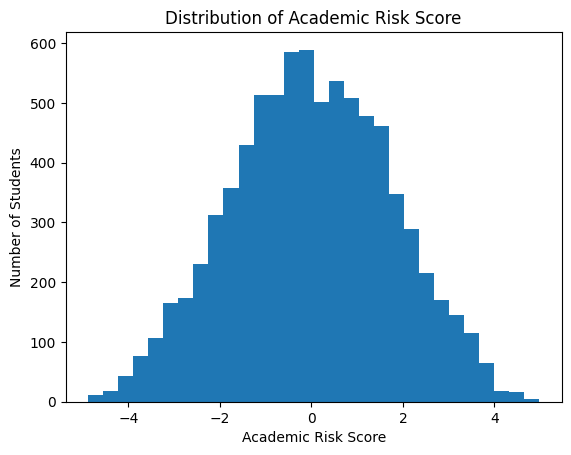

In [38]:
plt.hist(df["academic_risk_score"], bins=30)
plt.title("Distribution of Academic Risk Score")
plt.xlabel("Academic Risk Score")
plt.ylabel("Number of Students")
plt.show()

### Distribution of Gaming Intensity

The pie chart illustrates the proportion of students across different gaming
intensity categories. Most students fall into the light and moderate gaming
groups, while a smaller proportion are classified as heavy gamers. This indicates
that excessive gaming behavior is relatively uncommon but analytically important
when examining academic risk.

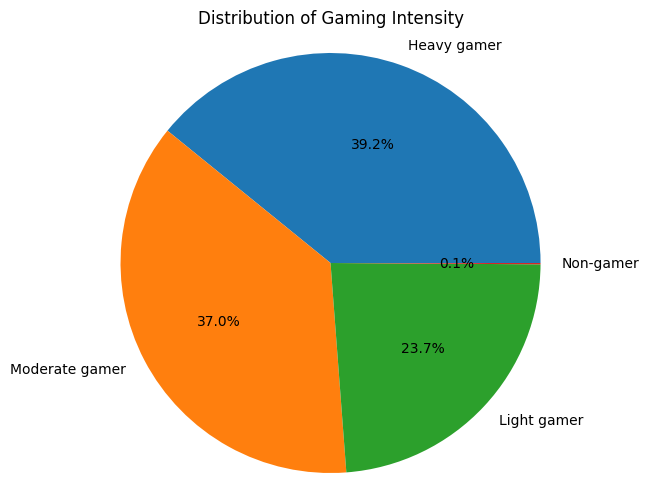

In [39]:
def gaming_category(hours):
    if hours == 0:
        return "Non-gamer"
    elif hours <= 2:
        return "Light gamer"
    elif hours <= 5:
        return "Moderate gamer"
    else:
        return "Heavy gamer"

df["gaming_intensity"] = df["gaming_hours"].apply(gaming_category)

gaming_counts = df['gaming_intensity'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(gaming_counts, labels=gaming_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Gaming Intensity')
plt.axis('equal')
plt.show()

### Relationship Between Academic Risk Score and Grades

The scatter plot shows a clear negative relationship between academic risk score
and academic grades. Students with higher risk scores tend to achieve lower grades,
while students with lower or negative risk scores generally perform better
academically. Although some variation exists, the overall trend supports the
interpretation that excessive gaming combined with reduced study and sleep is
associated with poorer academic outcomes.

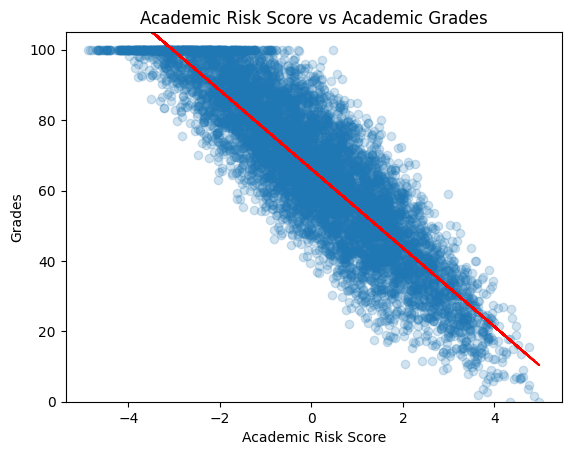

In [40]:
plt.scatter(df["academic_risk_score"], df["grades"], alpha=0.2)
m, b = np.polyfit(df["academic_risk_score"], df["grades"], 1)
plt.plot(df["academic_risk_score"], m*df["academic_risk_score"] + b, color="red")
plt.title("Academic Risk Score vs Academic Grades")
plt.xlabel("Academic Risk Score")
plt.ylabel("Grades")
plt.ylim(0, 105)
plt.show()


In [52]:
interpret_correlation(df, "academic_risk_score", "grades")

Correlation between academic_risk_score and grades: -0.88 (Strong negative correlation)


### Gaming Hours vs Academic Grades
This scatter plot shows a weak negative correlation between gaming hours and academic grades, indicated by the downward trend line.\
 Although the academic risk score was already analyzed, this plot is included to isolate and examine the direct relationship between gaming hours and grades without the influence of study and sleep.

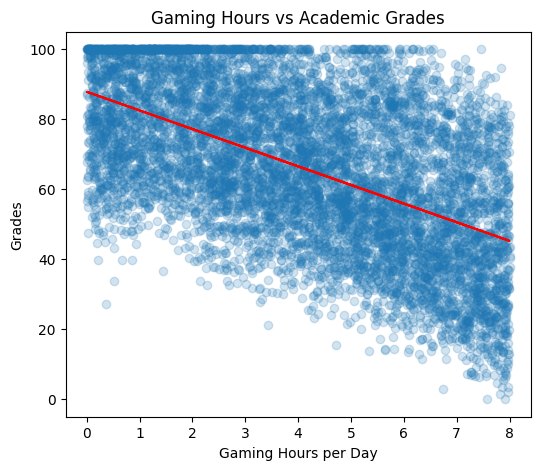

In [53]:
plt.figure(figsize=(6, 5))
plt.scatter(df["gaming_hours"], df["grades"], alpha=0.2)

m, b = np.polyfit(df["gaming_hours"], df["grades"], 1)
plt.plot(df["gaming_hours"], m*df["gaming_hours"] + b, color="red")

plt.title("Gaming Hours vs Academic Grades")
plt.xlabel("Gaming Hours per Day")
plt.ylabel("Grades")
plt.show()

In [64]:
interpret_correlation(df, "gaming_hours", "grades")

Correlation between gaming_hours and grades: -0.55 (Strong negative correlation)


### Sleep Hours vs Academic Grades
This scatter plot shows that students who sleep more tend to have higher grades on average, indicated by the upward trend line.
The pattern suggests that sleep has an although positive yet weak relationship with academic performance.

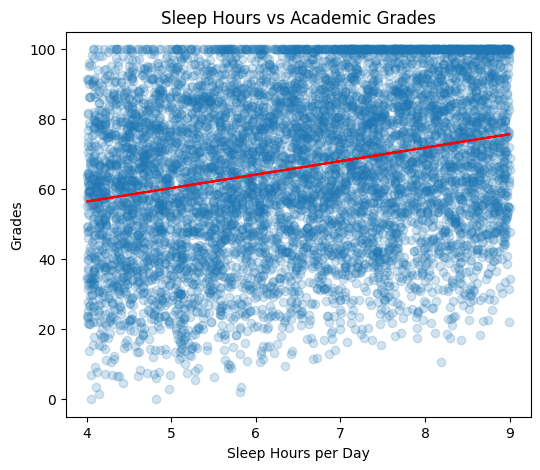

In [65]:
plt.figure(figsize=(6, 5))
plt.scatter(df["sleep_hours"], df["grades"], alpha=0.2)

m, b = np.polyfit(df["sleep_hours"], df["grades"], 1)
plt.plot(df["sleep_hours"], m*df["sleep_hours"] + b, color="red")

plt.title("Sleep Hours vs Academic Grades")
plt.xlabel("Sleep Hours per Day")
plt.ylabel("Grades")
plt.show()


In [75]:
interpret_correlation(df, "sleep_hours", "grades")

Correlation between sleep_hours and grades: 0.25 (Weak positive correlation)


### Average Gaming Hours by Stress Level
This chart was created to see how gaming behavior changes with stress.
It helps answer whether more stressed students game more or less.\
\
The results suggest that students with lower stress levels tend to game more, while highly stressed students usually game in moderation. This indicates that gaming may help students relax, but excessive gaming is more common among those with lower stress.

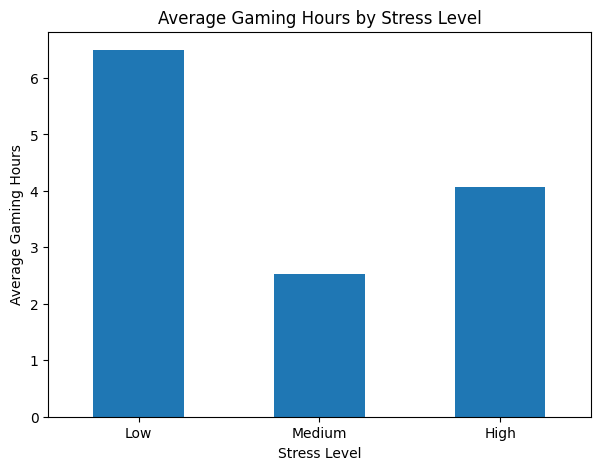

In [77]:
order = ["Low", "Medium", "High"]
df.groupby("stress_level")["gaming_hours"].mean().reindex(order).plot(kind="bar", figsize=(7, 5))

plt.title("Average Gaming Hours by Stress Level")
plt.xlabel("Stress Level")
plt.xticks(rotation=0)
plt.ylabel("Average Gaming Hours")
plt.show()

### Average Grades by Stress Level
This chart was created to understand how stress relates to academic performance.
It helps answer whether stressed students performing better or worse academically.\
\
The results show that students with higher stress levels tend to have higher grades, while students with lower stress levels generally achieve lower academic performance.\
\
**Key Takeaway:**\
Although stress is related to academic performance, the weak and inconsistent relationship between gaming and stress suggests that stress does not act as a clear mediator between gaming and poor grades.

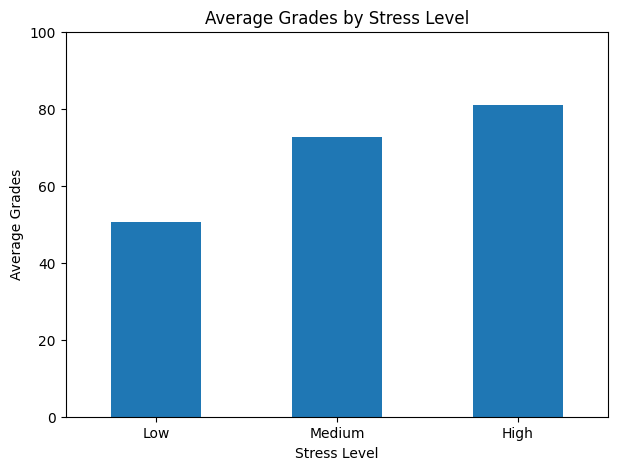

In [78]:
order = ["Low", "Medium", "High"]
df.groupby("stress_level")["grades"].mean().reindex(order).plot(kind="bar", figsize=(7, 5))
plt.title("Average Grades by Stress Level")
plt.xlabel("Stress Level")
plt.xticks(rotation=0)
plt.ylabel("Average Grades")
plt.ylim(0, 100)
plt.show()

### Academic Performance based on Gaming Genre
This boxplot was used to check whether different game genres are linked to different academic outcomes. \
The results show that grades are similar across all genres,\
suggesting that the type of game played alone does not significantly affect academic performance.

<Figure size 800x500 with 0 Axes>

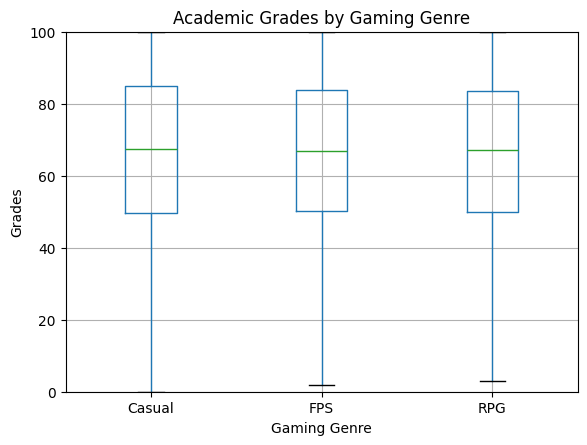

In [ ]:
plt.figure(figsize=(8, 5))
df.boxplot(column="grades", by="gaming_genre")

plt.title("Academic Grades by Gaming Genre")
plt.suptitle("")
plt.xlabel("Gaming Genre")
plt.ylabel("Grades")
plt.ylim(0, 100)
plt.show()

### Gaming Hours vs Reaction Time (Testing Cognitive Benefits)
This scatter plot was created to check whether gaming helps improve cognitive skills, measured using reaction time. The strong negative correlation suggests that higher gaming hours are generally associated with faster reaction times, supporting the idea that gaming may improve certain cognitive abilities.\

The main idea of this analysis to see if improving cognitive skills through gaming could translate into better academic performance.

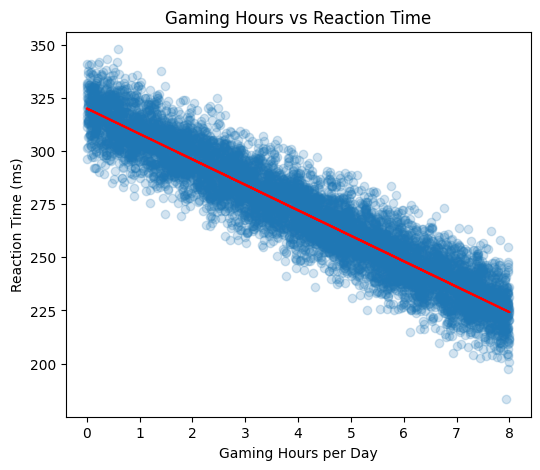

In [80]:
plt.figure(figsize=(6, 5))
plt.scatter(df["gaming_hours"], df["reaction_time_ms"], alpha=0.2)
m, b = np.polyfit(df["gaming_hours"], df["reaction_time_ms"], 1)
plt.plot(df["gaming_hours"], m*df["gaming_hours"] + b, color="red")
plt.title("Gaming Hours vs Reaction Time")
plt.xlabel("Gaming Hours per Day")
plt.ylabel("Reaction Time (ms)")
plt.show()

In [85]:
interpret_correlation(df, "reaction_time_ms", "gaming_hours")

Correlation between reaction_time_ms and gaming_hours: -0.94 (Strong negative correlation)


### Reaction Time (Cognitive Skill) vs Academic Grades
This scatter plot was created to see whether improved reaction time actually leads to better academic performance. \
Although the trend line slightly suggests that slower reaction times are linked to higher grades, the data points are **widely scattered**. \
This large spread shows that reaction time does not strongly predict academic grades. \
Meaning **faster cognitive responses do not necessarily translate into better academic outcomes**.

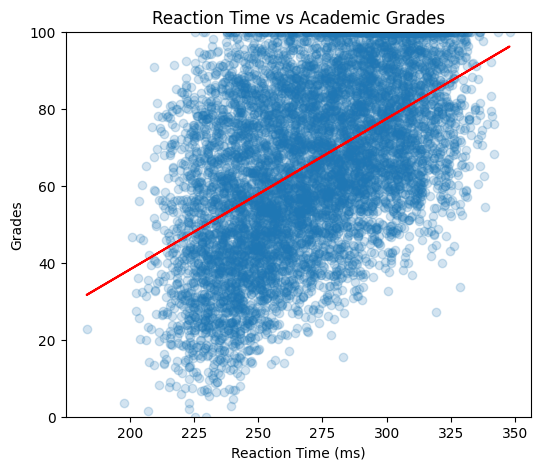

In [86]:
plt.figure(figsize=(6, 5))
plt.scatter(df["reaction_time_ms"], df["grades"], alpha=0.2)
m, b = np.polyfit(df["reaction_time_ms"], df["grades"], 1)
plt.plot(df["reaction_time_ms"], m*df["reaction_time_ms"] + b, color="red")
plt.title("Reaction Time vs Academic Grades")
plt.xlabel("Reaction Time (ms)")
plt.ylabel("Grades")
plt.ylim(0, 100)
plt.show()

In [90]:
interpret_correlation(df, "reaction_time_ms", "grades")

Correlation between reaction_time_ms and grades: 0.52 (Strong positive correlation)


### Attendance vs Academic Grades
This plot was created to check whether going to class more often is linked to better academic performance.\
The upward trend line shows that students with higher attendance tend to have slightly higher grades. \
This supports the idea that attendance is an important factor in academic success.

The purpose of this part was to first verify whether attendance positively effects academic performence.
And then verify whether having a gaming addiction negatively affecting attendance. 

The results concluded that there was no noticable correlation between gaming addiction and attendance.
This also means gaming does not appear to harm academic performance simply by keeping students out of class, and other factors such as stress, sleep, and study habits likely play a bigger role.

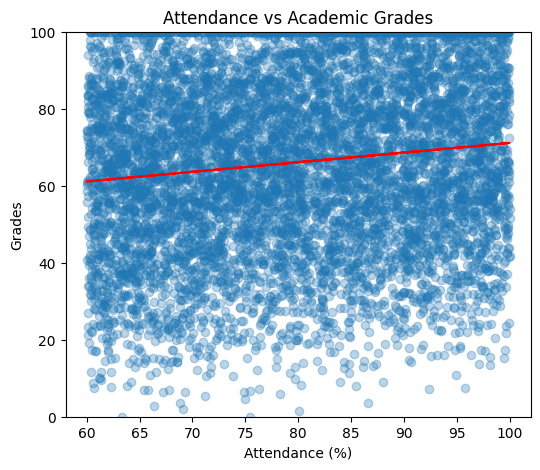

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df["attendance"], df["grades"], alpha=0.3)

m, b = np.polyfit(df["attendance"], df["grades"], 1)
plt.plot(df["attendance"],m * df["attendance"] + b,color="red")

plt.title("Attendance vs Academic Grades")
plt.xlabel("Attendance (%)")
plt.ylabel("Grades")
plt.ylim(0, 100)

plt.show()


In [97]:
interpret_correlation(df, "grades", "attendance")

Correlation between grades and attendance: 0.13 (Weak positive correlation)


### Gaming Addiction vs Attendance
This plot checks whether higher gaming addiction is linked to lower attendance. The flat trend line and scattered points show no strong relationship, suggesting that addiction alone does not clearly explain differences in class attendance.

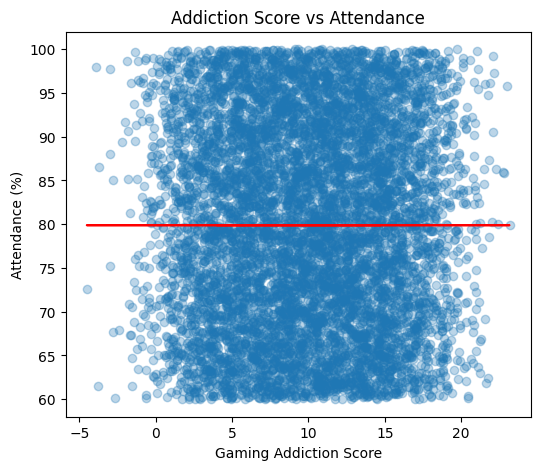

In [98]:

plt.figure(figsize=(6, 5))
plt.scatter(df["addiction_score"], df["attendance"], alpha=0.3)

m, b = np.polyfit(df["addiction_score"], df["attendance"], 1)
plt.plot(df["addiction_score"],m * df["addiction_score"] + b,color="red")

plt.title("Addiction Score vs Attendance")
plt.xlabel("Gaming Addiction Score")
plt.ylabel("Attendance (%)")

plt.show()


In [100]:
interpret_correlation(df, "attendance", "addiction_score")

Correlation between attendance and addiction_score: 0.0 (No noticeable correlation)


# Limitations:
### Sample Bias & Self-Reporting: 
The dataset relies on student records that may include self-reported hours for study, sleep, and gaming, which are subject to memory bias or social desirability bias.  

### Correlation vs. Causation: 
While a strong negative correlation exists between the Academic Risk Score and grades, this does not prove that gaming causes lower grades; it simply shows they occur together in this sample.  

### Missing Contextual Variables: 
The analysis does not account for external factors such as socioeconomic status, underlying learning disabilities, or the quality of study time versus the quantity.  

### Preprocessing Choices: 
Missing values were filled using the median and mode as a safeguard, and grades were capped at 100. While these choices preserve data integrity, they may slightly mask the impact of extreme outliers.

# Conclusion:

This project explored how different aspects of gaming relate to academic performance. The results show that while gaming can improve certain cognitive skills, such as reaction time, these improvements do not directly lead to better grades. Reaction time and academic performance showed a weak and scattered relationship, suggesting that cognitive speed alone is not an important factor in academic success.

The strongest finding of this analysis was the usefulness of the Academic Risk Score, which combined gaming hours, sleep, and study time. This combined score explained academic outcomes much more clearly than any single factor on its own. Students with a better balance of lower gaming and higher sleep and study time tended to perform better academically.

The analysis also showed that gaming addiction does not strongly affect class attendance, meaning that excessive gaming is unlikely to harm grades simply by keeping students out of class. Instead, the negative academic impact of gaming appears to be linked more to lifestyle imbalance, such as reduced sleep and study time, rather than the act of gaming itself.

Overall, the findings suggest that moderate gaming is not harmful, but maintaining balance is critical. Academic success in a gaming lifestyle depends on managing time, stress, sleep, and study habits rather than completely avoiding gaming.